# 03 - Análise de Regressão

Este notebook analisa a possibilidade de utilizar o conjunto de dados
para um problema de regressão, incluindo a definição da variável-alvo,
seleção de features, análise das relações com o alvo, divisão dos dados,
treinamento dos modelos e avaliação dos resultados.

In [36]:
import sys
sys.path.append("..")

import pandas as pd

from src.data_loader import load_data

In [ ]:
df = load_data("../data/processed/dataset_clean.csv") 

In [48]:
colunas_numericas_originais = [
    "mood_score",
    "stress_level",
    "fear_tolerance",
    "risk_tolerance",
    "humor_preference",
    "openness_score",
    "romance_interest",
    "social_media_hours_per_day",
    "streaming_subscription_count"
]

df[colunas_numericas_originais].describe().T

,count,mean,std,min,25%,50%,75%,max
mood_score,6000.0,6.195817,1.927168,1.0,4.9,6.2,7.5,10.0
stress_level,6000.0,5.010383,2.098021,1.0,3.6,5.0,6.5,10.0
fear_tolerance,6000.0,5.030900,2.349341,1.0,3.3,5.0,6.7,10.0
risk_tolerance,6000.0,5.027667,2.183606,1.0,3.5,5.0,6.6,10.0
humor_preference,6000.0,5.977350,2.114712,1.0,4.5,6.0,7.5,10.0
openness_score,6000.0,5.561600,2.133345,1.0,4.1,5.6,7.1,10.0
romance_interest,6000.0,5.056517,2.230248,1.0,3.4,5.0,6.6,10.0
social_media_hours_per_day,6000.0,2.587433,1.836051,0.0,1.2,2.2,3.5,12.0
streaming_subscription_count,6000.0,2.352667,1.313106,0.0,1.0,2.0,3.0,5.0


In [49]:
analise_numericas = pd.DataFrame({
    "quantidade_unicos": df[colunas_numericas_originais].nunique(),
    "media": df[colunas_numericas_originais].mean(),
    "desvio_padrao": df[colunas_numericas_originais].std(),
    "minimo": df[colunas_numericas_originais].min(),
    "maximo": df[colunas_numericas_originais].max()
})

analise_numericas

,quantidade_unicos,media,desvio_padrao,minimo,maximo
mood_score,91,6.195817,1.927168,1.0,10.0
stress_level,91,5.010383,2.098021,1.0,10.0
fear_tolerance,91,5.030900,2.349341,1.0,10.0
risk_tolerance,91,5.027667,2.183606,1.0,10.0
humor_preference,91,5.977350,2.114712,1.0,10.0
openness_score,91,5.561600,2.133345,1.0,10.0
romance_interest,91,5.056517,2.230248,1.0,10.0
social_media_hours_per_day,109,2.587433,1.836051,0.0,12.0
streaming_subscription_count,6,2.352667,1.313106,0.0,5.0


In [50]:
target = "social_media_hours_per_day"

correlacoes_pearson = (
    df[colunas_numericas_originais]
    .corr(method="pearson")[target]
    .drop(target)
    .sort_values(key=abs, ascending=False)
)

correlacoes_spearman = (
    df[colunas_numericas_originais]
    .corr(method="spearman")[target]
    .drop(target)
    .sort_values(key=abs, ascending=False)
)

print("Correlação de Pearson:")
display(correlacoes_pearson)

print("\nCorrelação de Spearman:")
display(correlacoes_spearman)

Correlação de Pearson:


romance_interest               -0.021843
streaming_subscription_count   -0.016353
mood_score                      0.015627
risk_tolerance                 -0.013496
fear_tolerance                 -0.008544
openness_score                  0.005307
stress_level                    0.002207
humor_preference                0.001052
Name: social_media_hours_per_day, dtype: float64


Correlação de Spearman:


romance_interest               -0.026390
streaming_subscription_count   -0.020762
risk_tolerance                 -0.011010
fear_tolerance                 -0.005349
mood_score                      0.005292
stress_level                    0.005098
openness_score                  0.002938
humor_preference                0.001999
Name: social_media_hours_per_day, dtype: float64

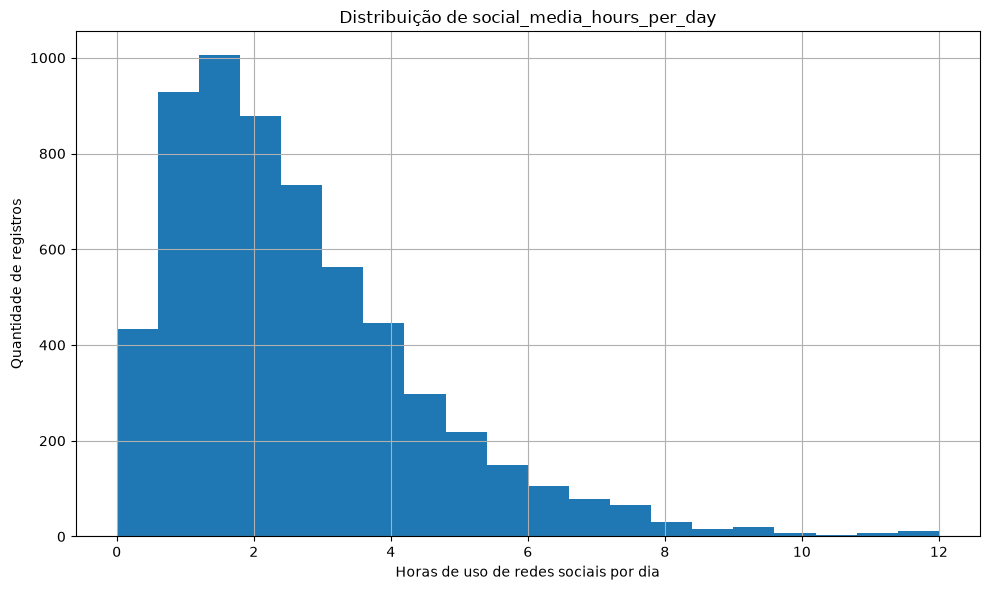

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

df[target].hist(bins=20)

plt.title("Distribuição de social_media_hours_per_day")
plt.xlabel("Horas de uso de redes sociais por dia")
plt.ylabel("Quantidade de registros")

plt.tight_layout()
plt.show()

In [51]:
X = df[colunas_numericas_originais].drop(columns=target)

y = df[target]

In [52]:
from sklearn.feature_selection import SelectKBest, f_regression

selecionador = SelectKBest(score_func=f_regression, k=5)

selecionador.fit(X, y)

scores = pd.Series(
    selecionador.scores_,
    index=X.columns
).sort_values(ascending=False)

print("Ranking de importância (F-score):")
print(scores)

features_selecionadas_kbest = X.columns[selecionador.get_support()]

print("\nFeatures selecionadas pelo SelectKBest:")
print(list(features_selecionadas_kbest))

Ranking de importância (F-score):
romance_interest                2.863168
streaming_subscription_count    1.604320
mood_score                      1.465038
risk_tolerance                  1.092606
fear_tolerance                  0.437922
openness_score                  0.168941
stress_level                    0.029218
humor_preference                0.006632
dtype: float64

Features selecionadas pelo SelectKBest:
['mood_score', 'fear_tolerance', 'risk_tolerance', 'romance_interest', 'streaming_subscription_count']


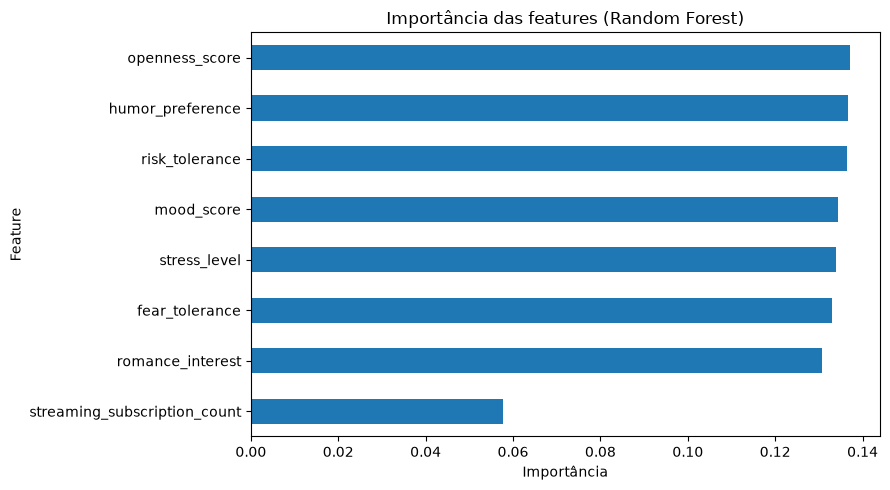

In [53]:
from sklearn.ensemble import RandomForestRegressor

modelo_rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

modelo_rf.fit(X, y)

importancias = pd.Series(
    modelo_rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(9, 5))

importancias.plot(kind="barh")

plt.title("Importância das features (Random Forest)")
plt.xlabel("Importância")
plt.ylabel("Feature")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [54]:
from scipy import stats
import pandas as pd

cat_cols = df.select_dtypes(
    include=["str", "category"]
).columns.tolist()

target_reg = "social_media_hours_per_day"

results = []

for col in cat_cols:

    groups = [
        group[target_reg].dropna().values
        for _, group in df.groupby(col)
    ]

    if len(groups) > 1:
        stat, p_val = stats.kruskal(*groups)

        results.append({
            "feature": col,
            "estatistica_H": stat,
            "p_valor": p_val,
            "significativo": "SIM" if p_val < 0.05 else "NÃO"
        })

df_sinal_cat = (
    pd.DataFrame(results)
    .sort_values(by="p_valor")
)

print(df_sinal_cat)

                         feature  estatistica_H   p_valor significativo
2               personality_type       7.071086  0.029143           SIM
13  preferred_streaming_platform      12.125243  0.059232           NÃO
17              preferred_device       7.931433  0.094122           NÃO
23        book_reading_frequency       5.575222  0.233196           NÃO
0                      age_group       5.185900  0.268749           NÃO
19            favorite_movie_era       5.140445  0.273188           NÃO
4            favorite_game_genre       9.826497  0.277415           NÃO
24       recommended_movie_genre       9.661413  0.289599           NÃO
5           favorite_music_genre       9.430765  0.307269           NÃO
18        preferred_movie_length       3.203584  0.361289           NÃO
12                income_bracket       4.141570  0.387185           NÃO
10               education_level       3.148991  0.533209           NÃO
3                        hobbies    1515.824014  0.582688       

In [55]:
features_reg = [
    "mood_score",
    "fear_tolerance",
    "risk_tolerance",
    "romance_interest",
    "streaming_subscription_count"
]

target_reg = "social_media_hours_per_day"

X_reg = df[features_reg]
y_reg = df[target_reg]

In [58]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_reg,
    y_reg,
    test_size=0.2,
    random_state=42
)

In [57]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_reg,
    y_reg,
    test_size=0.2,
    random_state=42
)

In [59]:
from sklearn.linear_model import LinearRegression

modelo_linear = LinearRegression()

modelo_linear.fit(X_train, y_train)

y_pred_linear = modelo_linear.predict(X_test)

In [33]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_linear = mean_absolute_error(y_test, y_pred_linear)
rmse_linear = np.sqrt(mean_squared_error(y_test, y_pred_linear))
r2_linear = r2_score(y_test, y_pred_linear)

print("Regressão Linear")
print("MAE:", mae_linear)
print("RMSE:", rmse_linear)
print("R²:", r2_linear)

Regressão Linear
MAE: 1.3594805312121458
RMSE: 1.7758452852759679
R²: 0.00044008040868959153


In [60]:
from sklearn.ensemble import RandomForestRegressor

modelo_rf_reg = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

modelo_rf_reg.fit(X_train, y_train)

y_pred_rf = modelo_rf_reg.predict(X_test)

In [61]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Regressor")
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R²:", r2_rf)

Random Forest Regressor
MAE: 1.4306858333333334
RMSE: 1.8356633004175904
R²: -0.06803289976499527
